# 🚗 DoorDash Delivery Prediction
## Notebook 04 — Modeling

**Goal:** Train regression models to predict `total_delivery_duration_mins`. Compare models and pick the best one.

**Problem Type:** Regression

**Target:** `total_delivery_duration_mins` — how long in minutes will the delivery take?

**Metrics used:**
- **MAE** — Mean Absolute Error (avg minutes off)
- **RMSE** — Root Mean Squared Error (penalises big errors more)
- **R²** — How much variance the model explains (1.0 = perfect)

**Author:** Divyargarg

---

In [1]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ── CELL 2: Load Feature Data ─────────────────────────────────────────
df = pd.read_csv('../data/features/features_data.csv')

print(f'✅ Feature data loaded!')
print(f'📊 Shape: {df.shape}')
df.head()

✅ Feature data loaded!
📊 Shape: (197283, 16)


,store_primary_category,order_protocol,total_items,subtotal,min_item_price,max_item_price,total_onshift_dashers,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,total_delivery_duration_mins,order_hour,order_day_of_week,order_month,is_weekend,is_rush_hour,is_late_night
0,american,1.0,4,3441.0,557,1239.0,33.0,446,861.0,62.983333,22,4,2,0,0,1
1,mexican,2.0,1,1900.0,1400,1400.0,1.0,446,690.0,67.066667,21,1,2,0,0,0
2,american,1.0,1,1900.0,1900,1900.0,1.0,446,690.0,29.683333,20,3,1,0,1,0
3,american,1.0,6,6387.5,600,1800.0,1.0,446,289.0,51.250000,21,1,2,0,0,0
4,american,1.0,3,3900.0,1100,1600.0,6.0,446,650.0,39.833333,2,6,2,1,0,1


In [3]:
# ── CELL 3: Separate Features & Target ───────────────────────────────
TARGET = 'total_delivery_duration_mins'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'✅ Features (X): {X.shape}')
print(f'✅ Target  (y): {y.shape}')
print(f'\n📊 Target Summary:')
print(y.describe().round(2))

✅ Features (X): (197283, 15)
✅ Target  (y): (197283,)

📊 Target Summary:
count    197283.00
mean         47.53
std          18.04
min           1.68
25%          35.07
50%          44.32
75%          56.32
max         179.85
Name: total_delivery_duration_mins, dtype: float64


In [4]:
# ── CELL 4: Encode Categorical Columns ───────────────────────────────
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

for col in cat_cols:
    n_unique = X[col].nunique()
    if n_unique <= 10:
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
        X = pd.concat([X.drop(columns=[col]), dummies], axis=1)
        print(f'  ✅ One-hot encoded: {col} ({n_unique} categories)')
    else:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  ✅ Label encoded: {col} ({n_unique} categories)')

print(f'\n📊 X shape after encoding: {X.shape}')

Categorical columns to encode: ['store_primary_category']
  ✅ Label encoded: store_primary_category (74 categories)

📊 X shape after encoding: (197283, 15)


In [5]:
# ── CELL 5: Train / Validation / Test Split ───────────────────────────
# 70% train | 15% validation | 15% test

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'✅ Train      : {X_train.shape[0]} rows')
print(f'✅ Validation : {X_val.shape[0]} rows')
print(f'✅ Test       : {X_test.shape[0]} rows')

✅ Train      : 138098 rows
✅ Validation : 29592 rows
✅ Test       : 29593 rows


In [6]:
# ── CELL 6: Scale Features ────────────────────────────────────────────
# Fit on TRAIN only — prevents data leakage!

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('✅ Scaling complete!')
print('⚠️  Scaler fit on TRAIN only — applied separately to val/test (no data leakage)')

✅ Scaling complete!
⚠️  Scaler fit on TRAIN only — applied separately to val/test (no data leakage)


In [7]:
# ── CELL 7: Helper — Evaluate Any Regression Model ───────────────────
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)

    mae  = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2   = r2_score(y_v, y_pred)

    results = {
        'Model': name,
        'MAE (mins)' : round(mae, 3),
        'RMSE (mins)': round(rmse, 3),
        'R²'         : round(r2, 4)
    }
    return results, model, y_pred

print('✅ evaluate_model() ready!')

✅ evaluate_model() ready!


In [8]:
# ── CELL 8: Model 1 — Linear Regression (Baseline) ───────────────────
lr_results, lr_model, lr_preds = evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_scaled, y_train,
    X_val_scaled, y_val
)
print('📊 Linear Regression:')
for k, v in lr_results.items():
    if k != 'Model':
        print(f'  {k}: {v}')

📊 Linear Regression:
  MAE (mins): 12.468
  RMSE (mins): 16.739
  R²: 0.1413


In [9]:
# ── CELL 9: Model 2 — Random Forest Regressor ────────────────────────
rf_results, rf_model, rf_preds = evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train,   # Tree models don't need scaling
    X_val, y_val
)
print('📊 Random Forest:')
for k, v in rf_results.items():
    if k != 'Model':
        print(f'  {k}: {v}')

📊 Random Forest:
  MAE (mins): 11.876
  RMSE (mins): 15.905
  R²: 0.2247


In [10]:
# ── CELL 10: Model 3 — XGBoost Regressor ─────────────────────────────
xgb_results, xgb_model, xgb_preds = evaluate_model(
    'XGBoost',
    XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    X_train, y_train,
    X_val, y_val
)
print('📊 XGBoost:')
for k, v in xgb_results.items():
    if k != 'Model':
        print(f'  {k}: {v}')

📊 XGBoost:
  MAE (mins): 11.348
  RMSE (mins): 15.383
  R²: 0.2748


📊 MODEL COMPARISON (Validation Set):
                   MAE (mins)  RMSE (mins)      R²
Model                                             
Linear Regression      12.468       16.739  0.1413
Random Forest          11.876       15.905  0.2247
XGBoost                11.348       15.383  0.2748

💡 Lower MAE/RMSE = better | Higher R² = better


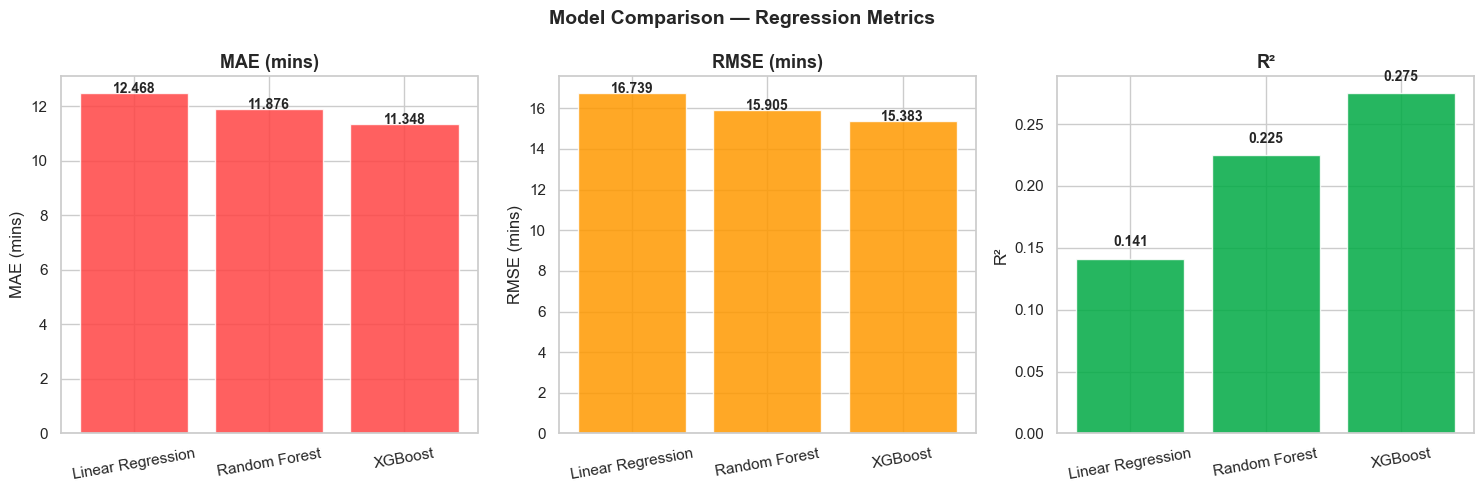

✅ Saved!


In [11]:
# ── CELL 11: Compare All Models ───────────────────────────────────────
results_df = pd.DataFrame([lr_results, rf_results, xgb_results]).set_index('Model')

print('📊 MODEL COMPARISON (Validation Set):')
print(results_df.to_string())
print('\n💡 Lower MAE/RMSE = better | Higher R² = better')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE (mins)', 'RMSE (mins)', 'R²']
colors  = ['#FF4444', '#FF9900', '#00AA44']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df.index, results_df[metric], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=10)

plt.suptitle('Model Comparison — Regression Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_model_comparison.png', dpi=150)
plt.show()
print('✅ Saved!')

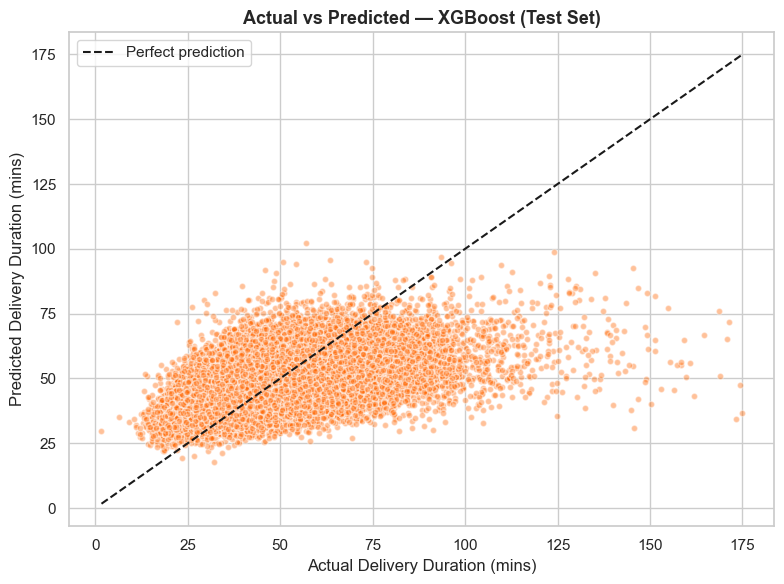


📊 TEST SET FINAL RESULTS — XGBoost:
  MAE  : 11.28 minutes
  RMSE : 15.24 minutes
  R²   : 0.2724

💡 Interpretation: On average the model is off by 11.3 minutes


In [12]:
# ── CELL 12: Actual vs Predicted Plot — Best Model ────────────────────
# Change best_model to whichever won above
best_model = xgb_model
best_name  = 'XGBoost'

y_pred_test = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.4, color='#FF6600', edgecolors='white', s=20)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect prediction')
plt.title(f'Actual vs Predicted — {best_name} (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Delivery Duration (mins)')
plt.ylabel('Predicted Delivery Duration (mins)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/04_actual_vs_predicted.png', dpi=150)
plt.show()

test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = r2_score(y_test, y_pred_test)
print(f'\n📊 TEST SET FINAL RESULTS — {best_name}:')
print(f'  MAE  : {test_mae:.2f} minutes')
print(f'  RMSE : {test_rmse:.2f} minutes')
print(f'  R²   : {test_r2:.4f}')
print(f'\n💡 Interpretation: On average the model is off by {test_mae:.1f} minutes')

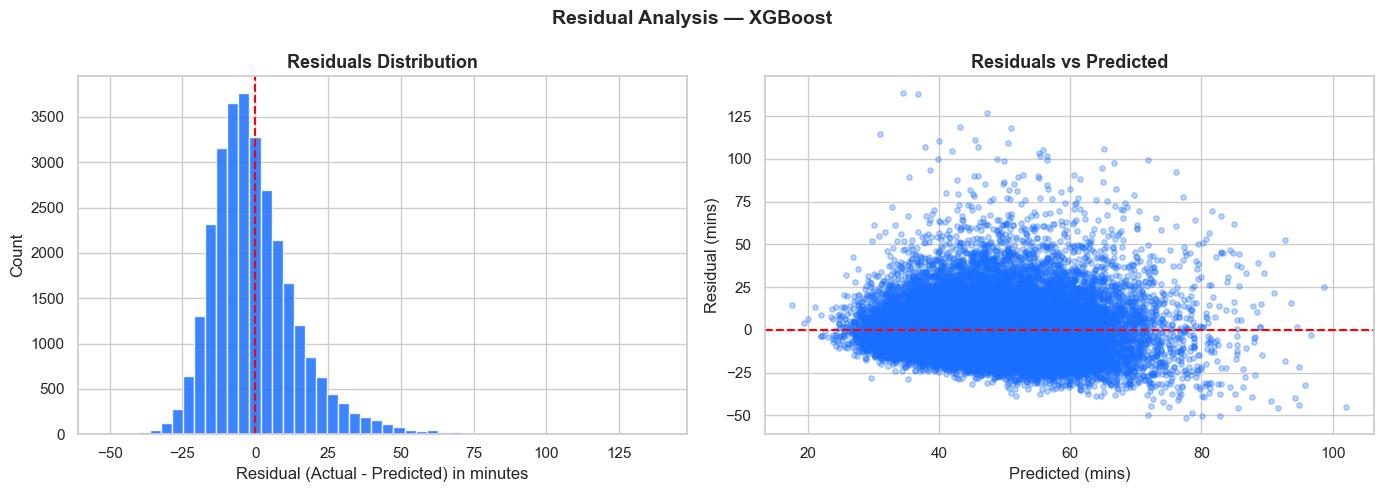

✅ Saved!


In [13]:
# ── CELL 13: Residuals Plot ───────────────────────────────────────────
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, color='#1a6eff', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted) in minutes')
axes[0].set_ylabel('Count')

# Residuals vs predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.3, color='#1a6eff', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted (mins)')
axes[1].set_ylabel('Residual (mins)')

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_residuals.png', dpi=150)
plt.show()
print('✅ Saved!')

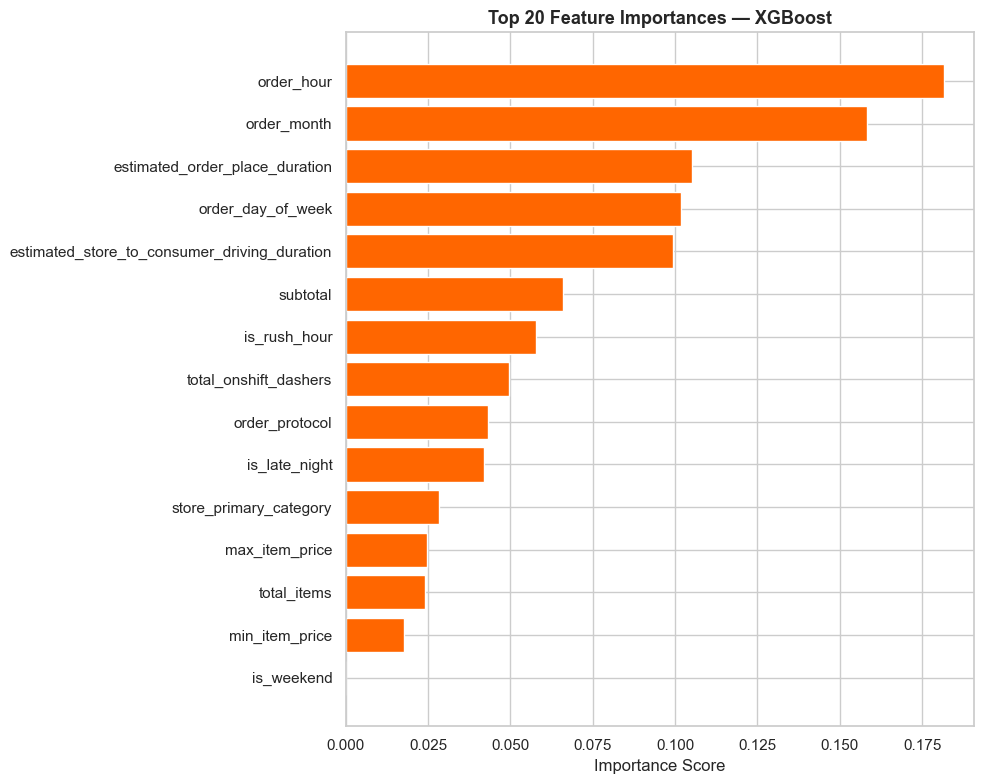

✅ Saved!


In [14]:
# ── CELL 14: Feature Importance ───────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature'   : X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(20)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['feature'], importance_df['importance'],
             color='#FF6600', edgecolor='white')
    plt.title(f'Top 20 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../outputs/figures/04_feature_importance.png', dpi=150)
    plt.show()
    print('✅ Saved!')

In [15]:
# ── CELL 15: Save Best Model ──────────────────────────────────────────
with open('../outputs/models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save test results for notebook 05
test_results = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred_test})
test_results.to_csv('../outputs/models/test_predictions.csv', index=False)

print(f'✅ Model saved → outputs/models/best_model.pkl')
print(f'✅ Predictions saved → outputs/models/test_predictions.csv')

✅ Model saved → outputs/models/best_model.pkl
✅ Predictions saved → outputs/models/test_predictions.csv


## 📝 Modeling Decisions
*(Fill this in after running all cells)*

- **Best model:** 
- **Why it won:** 
- **MAE on test set (avg minutes off):** 
- **R² on test set:** 
- **Top 3 most important features:** 
- **What the residuals tell us:** 
- **Next steps to improve:** 